# Sentiment Scope - End-to-End NLP Text Classification

**Track**: NLP Engineering | **Lesson**: Text Classification & NLP Pipelines  
**The School of Artificial Intelligence (SAI)** • NAVTTC • Corvit Systems

---

### What We'll Build

A **sentiment classifier** that predicts whether an AI course student review is **Positive** or **Negative**.  

We'll go step by step:

1. **Load** the dataset (CSV of student reviews)
2. **Preprocess** the text using NLTK (clean -> tokenize -> stopwords -> stem)
3. **Vectorize** using TF-IDF (convert words to numbers)
4. **Train** a Logistic Regression model
5. **Evaluate** with accuracy, F1-score, confusion matrix
6. **Predict** on a brand new review

... 

> **Real-world example**: This is exactly how companies like Amazon analyze product reviews at scale - preprocess text, vectorize it, train a classifier, deploy it.

---
## Step 0: Import Libraries

We need:
- **pandas** → load and explore data
- **nltk** → NLP preprocessing (tokenization, stopwords, stemming)
- **scikit-learn** → TF-IDF, Logistic Regression, evaluation metrics

In [1]:
# Core Libraries 
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK for NLP preprocessing
import nltk
# nltk.download('stopwords', quiet=True)
# nltk.download('punkt', quiet=True)
# nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import TreebankWordTokenizer
from nltk.stem import PorterStemmer, SnowballStemmer

# Scikit-learn for ML 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 1: Load the Dataset

Our dataset is a CSV file with two columns:
- **review_text** → the student's review (raw text)
- **sentiment** → the label: `1` = Positive, `0` = Negative

This is a **small dataset** (~120 reviews). That's intentional!  
In real industry projects, you often start with small labeled data. The lesson: **preprocessing quality matters more than data volume** on small datasets.

In [2]:
# Load the CSV
df = pd.read_csv('data/ai_course_reviews.csv')

# Quick look at the data
print(f'Total reviews : {len(df)}')
print(f'Columns       : {list(df.columns)}')
print(f'Any nulls?    : {df.isnull().sum().sum()}')
print(f'Duplicates?   : {df.duplicated().sum()}')
print()

# Class distribution
print('Class Distribution:')
print(df['sentiment'].value_counts())
print()

# Show first 5 rows
df.head()

Total reviews : 118
Columns       : ['review_text', 'sentiment']
Any nulls?    : 0
Duplicates?   : 0

Class Distribution:
sentiment
1    59
0    59
Name: count, dtype: int64



,review_text,sentiment
0,The hands-on labs were incredibly well structu...,1
1,I struggled with the pace of the course and fe...,0
2,The instructor explained backpropagation so cl...,1
3,Curriculum felt outdated compared to what the ...,0
4,Building a real project from day one gave me c...,1


In [3]:
# Let's look at some actual reviews to understand the data
print('=== POSITIVE Reviews ===')
for text in df[df['sentiment'] == 1]['review_text'].head(3).values:
    print(f'  {text[:100]}...')

print()
print('=== NEGATIVE Reviews ===')
for text in df[df['sentiment'] == 0]['review_text'].head(3).values:
    print(f'  {text[:100]}...')

=== POSITIVE Reviews ===
  The hands-on labs were incredibly well structured and helped me understand neural networks from scra...
  The instructor explained backpropagation so clearly that even complex math felt approachable...
  Building a real project from day one gave me confidence I never had with online tutorials...

=== NEGATIVE Reviews ===
  I struggled with the pace of the course and felt left behind after the second week...
  Curriculum felt outdated compared to what the industry actually uses today...
  The support resources were minimal and questions in the forum went unanswered for days...


---
## Step 2: NLP Text Preprocessing Pipeline

**Why preprocess?**  
Raw text is messy — uppercase, punctuation, irrelevant words. The model can't understand raw text.  
We need to **clean it** and **normalize it** so the model sees consistent patterns.

Our pipeline has **4 steps**:

```
Raw Text → [1] Clean → [2] Tokenize → [3] Remove Stopwords → [4] Stem → Clean Text
```

Let's build each step one by one.

### Step 2.1: Text Cleaning (Lowercasing + Noise Removal)

**What**: Convert to lowercase, remove punctuation, numbers, special characters, extra spaces.  
**Why**: "AMAZING" and "amazing" should be the same word to our model. Punctuation adds no sentiment signal.

In [4]:
def clean_text(text):
    """Lowercase + remove everything except letters and spaces."""
    text = text.lower()                        # AMAZING -> amazing
    text = re.sub(r'[^a-z\s]', ' ', text)      # remove punctuation, numbers, special chars
    text = re.sub(r'\s+', ' ', text).strip()    # collapse multiple spaces
    return text


# Demo 
sample = "The instructor's hands-on labs were INCREDIBLY well-structured!! 10/10 would recommend."
print(f'Before: {sample}')
print(f'After : {clean_text(sample)}')

Before: The instructor's hands-on labs were INCREDIBLY well-structured!! 10/10 would recommend.
After : the instructor s hands on labs were incredibly well structured would recommend


### Step 2.2: Tokenization (NLTK)

**What**: Split the cleaned text into individual words (called **tokens**).  
**Why**: The model needs to work with individual words, not whole sentences.

We use NLTK's `TreebankWordTokenizer` — it handles English text smartly (e.g., splits contractions).

In [5]:
# Initialize NLTK tokenizer
tokenizer = TreebankWordTokenizer()


def tokenize(text):
    """Split text into individual word tokens."""
    return tokenizer.tokenize(text)


# Demo 
cleaned = clean_text(sample)
tokens = tokenize(cleaned)
print(f'Text  : {cleaned}')
print(f'Tokens: {tokens}')
print(f'Count : {len(tokens)} tokens')

Text  : the instructor s hands on labs were incredibly well structured would recommend
Tokens: ['the', 'instructor', 's', 'hands', 'on', 'labs', 'were', 'incredibly', 'well', 'structured', 'would', 'recommend']
Count : 12 tokens


### Step 2.3: Stopword Removal (NLTK)

**What**: Remove high-frequency words that carry no sentiment meaning — "the", "is", "and", "a", etc.  
**Why**: These words appear in BOTH positive and negative reviews, so they're noise for our classifier.

We use NLTK's built-in English stopword list.

In [6]:
# Load NLTK English stopwords
stop_words = set(stopwords.words('english'))

print(f'Total stopwords: {len(stop_words)}')
print(f'Examples: {sorted(list(stop_words))[:15]}')

Total stopwords: 198
Examples: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]


In [7]:
def remove_stopwords(tokens):
    """Remove stopwords. Keep words with 2+ characters."""
    return [word for word in tokens if word not in stop_words and len(word) > 1]


# Demo 
filtered = remove_stopwords(tokens)
print(f'Before ({len(tokens)} tokens): {tokens}')
print(f'After  ({len(filtered)} tokens): {filtered}')
print(f'Removed: {set(tokens) - set(filtered)}')

Before (12 tokens): ['the', 'instructor', 's', 'hands', 'on', 'labs', 'were', 'incredibly', 'well', 'structured', 'would', 'recommend']
After  (8 tokens): ['instructor', 'hands', 'labs', 'incredibly', 'well', 'structured', 'would', 'recommend']
Removed: {'the', 'on', 'were', 's'}


### Step 2.4: Stemming (NLTK PorterStemmer)

**What**: Reduce words to their **root form** by chopping off suffixes.  
**Why**: "learning", "learned", "learns" should all map to "learn" — they carry the same meaning.

**Porter Stemmer** is the classic, fast algorithm. It's aggressive but effective for classification.

| Word | Stemmed |
|------|--------|
| learning | learn |
| structured | structur |
| incredibly | incred |

In [8]:
# Initialize Porter Stemmer
stemmer = PorterStemmer()


def stem_tokens(tokens):
    """Apply Porter Stemming to each token."""
    return [stemmer.stem(word) for word in tokens]


# Demo
stemmed = stem_tokens(filtered)
print('Before vs After Stemming:')
for original, stem in zip(filtered, stemmed):
    changed = ' ← changed' if original != stem else ''
    print(f'  {original:>15s} → {stem}{changed}')

Before vs After Stemming:
       instructor → instructor
            hands → hand ← changed
             labs → lab ← changed
       incredibly → incred ← changed
             well → well
       structured → structur ← changed
            would → would
        recommend → recommend


### Step 2.5: Combine Everything into One Function

Now we chain all 4 steps into a single `preprocess()` function.

In [9]:
def preprocess(text):
    """
    Complete NLP preprocessing pipeline:
    Raw text -> clean -> tokenize -> remove stopwords -> stem -> joined string
    """
    text = clean_text(text)           # Step 1: lowercase + remove noise
    tokens = tokenize(text)           # Step 2: split into words
    tokens = remove_stopwords(tokens) # Step 3: remove stopwords
    tokens = stem_tokens(tokens)      # Step 4: stem to root form
    return ' '.join(tokens)           # Join back into a string


# Demo: Full Pipeline
print('FULL PIPELINE DEMO')
print('=' * 60)
demo = "The hands-on labs were INCREDIBLY well-structured and helped me understand neural networks from scratch"
print(f'INPUT : {demo}')
print(f'OUTPUT: {preprocess(demo)}')

FULL PIPELINE DEMO
INPUT : The hands-on labs were INCREDIBLY well-structured and helped me understand neural networks from scratch
OUTPUT: hand lab incred well structur help understand neural network scratch


### Step 2.6: Apply Preprocessing to All Reviews

In [10]:
# Apply our preprocessing function to every review
df['clean_text'] = df['review_text'].apply(preprocess)

# Compare before and after
print('Before vs After Preprocessing:')
print('-' * 60)
for i in range(3):
    print(f'RAW   : {df["review_text"].iloc[i][:80]}...')
    print(f'CLEAN : {df["clean_text"].iloc[i][:80]}...')
    print()

Before vs After Preprocessing:
------------------------------------------------------------
RAW   : The hands-on labs were incredibly well structured and helped me understand neura...
CLEAN : hand lab incred well structur help understand neural network scratch...

RAW   : I struggled with the pace of the course and felt left behind after the second we...
CLEAN : struggl pace cours felt left behind second week...

RAW   : The instructor explained backpropagation so clearly that even complex math felt ...
CLEAN : instructor explain backpropag clearli even complex math felt approach...



---
## Step 3: TF-IDF Vectorization (Words → Numbers)

**The Problem**: Machine learning models need **numbers**, not text.  
**The Solution**: **TF-IDF** (Term Frequency–Inverse Document Frequency)

### How TF-IDF Works (Simple Explanation)

- **TF** (Term Frequency): How often a word appears in ONE review
- **IDF** (Inverse Document Frequency): How rare the word is across ALL reviews
- **TF-IDF = TF × IDF**: Words that are frequent in one review but rare overall get HIGH scores

**Example**:  
- "the" appears everywhere → low TF-IDF (not useful)  
- "incredible" appears only in positive reviews → high TF-IDF (very useful!)

In [11]:
# Separate features (X) and labels (y)
X = df['clean_text']   # preprocessed review text
y = df['sentiment']    # labels: 1 = positive, 0 = negative

print(f'Features shape: {X.shape}')
print(f'Labels shape  : {y.shape}')
print(f'Label balance : Positive={y.sum()}, Negative={(y==0).sum()}')

Features shape: (118,)
Labels shape  : (118,)
Label balance : Positive=59, Negative=59


---
## Step 4: Train/Test Split

We split the data: **80%** for training, **20%** for testing.  
We use `stratify=y` to keep the same positive/negative ratio in both sets.

In [12]:
# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f'Training set: {len(X_train)} reviews')
print(f'Test set    : {len(X_test)} reviews')
print(f'Train balance: Pos={y_train.sum()}, Neg={(y_train==0).sum()}')
print(f'Test balance : Pos={y_test.sum()}, Neg={(y_test==0).sum()}')

Training set: 94 reviews
Test set    : 24 reviews
Train balance: Pos=47, Neg=47
Test balance : Pos=12, Neg=12


---
## Step 5: TF-IDF + Model Training

Now we:
1. **Fit TF-IDF** on training data (learn the vocabulary)
2. **Transform** both train and test data into TF-IDF vectors
3. **Train** Logistic Regression on the TF-IDF vectors

In [13]:
# Step 5a: Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # use single words AND pairs of words (bigrams)
    max_features=3000,    # keep top 3000 features only
    min_df=2,             # ignore words that appear in fewer than 2 reviews
    max_df=0.95,          # ignore words that appear in more than 95% of reviews
)

# Fit on training data, transform both
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Vocabulary size: {len(tfidf.get_feature_names_out())} features')
print(f'Train matrix   : {X_train_tfidf.shape}')
print(f'Test matrix    : {X_test_tfidf.shape}')
print(f'\nSample features: {list(tfidf.get_feature_names_out()[:10])}')

Vocabulary size: 169 features
Train matrix   : (94, 169)
Test matrix    : (24, 169)

Sample features: ['access', 'actual', 'actual understand', 'ai', 'altern', 'appreci', 'approach', 'assign', 'basic', 'behind']


In [14]:
# Step 5b: Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

print('Model trained successfully!')

Model trained successfully!


---
## Step 6: Model Evaluation

Let's see how well our model performs on the **test set** (data it has never seen).

In [15]:
# Predict on test set
y_pred = model.predict(X_test_tfidf)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.2%}')
print()

# Detailed Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Accuracy: 91.67%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      1.00      0.92        12
    Positive       1.00      0.83      0.91        12

    accuracy                           0.92        24
   macro avg       0.93      0.92      0.92        24
weighted avg       0.93      0.92      0.92        24



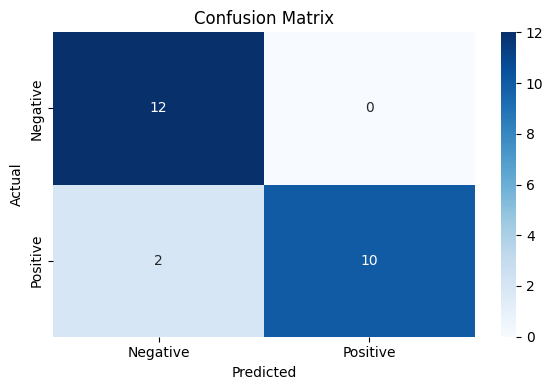

In [16]:
# Confusion Matrix - visual way to see correct vs incorrect predictions
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# How to read this:
# Top-left: Correctly predicted Negative (True Negative)
# Bottom-right: Correctly predicted Positive (True Positive)
# Top-right: Was Negative, predicted Positive (False Positive)
# Bottom-left: Was Positive, predicted Negative (False Negative)

---
## Step 7: Top Features (What Words Drive the Predictions?)

One of the best things about Logistic Regression — it's **interpretable**.  
We can look at the model's coefficients to see which words push toward Positive vs Negative.

In [17]:
# Get feature names and their weights
feature_names = tfidf.get_feature_names_out()
coefficients  = model.coef_[0]

# Top 10 positive and negative words
top_positive_idx = np.argsort(coefficients)[-10:][::-1]
top_negative_idx = np.argsort(coefficients)[:10]

print(f'{"TOP POSITIVE WORDS":<30} {"TOP NEGATIVE WORDS"}')
print(f'{"-"*30} {"-"*30}')
for i in range(10):
    pos_word   = feature_names[top_positive_idx[i]]
    pos_weight = coefficients[top_positive_idx[i]]
    neg_word   = feature_names[top_negative_idx[i]]
    neg_weight = coefficients[top_negative_idx[i]]
    print(f'  {pos_word:<20} {pos_weight:>+.3f}      {neg_word:<20} {neg_weight:>+.3f}')

TOP POSITIVE WORDS             TOP NEGATIVE WORDS
------------------------------ ------------------------------
  ml                   +0.755      cours                -0.694
  deploy               +0.643      legitim              -0.561
  genuin               +0.610      student              -0.556
  build                +0.605      despit               -0.519
  confid               +0.602      week                 -0.509
  end                  +0.599      assign               -0.495
  gave                 +0.542      time                 -0.473
  understand           +0.514      clearli              -0.469
  instructor           +0.508      promis               -0.460
  model                +0.504      deadlin              -0.457


---
## Step 8: Predict on a New Review!

This is the final test — let's give our model a **brand new review** it has never seen  
and see if it can correctly predict the sentiment.

In [18]:
# A brand new review (not in our dataset)
new_review = "The course was a complete waste of time and the instructor never explained anything clearly"

print('=' * 60)
print('SINGLE REVIEW PREDICTION')
print('=' * 60)

# Step 1: Show the raw input
print(f'\nRaw Review:')
print(f'   "{new_review}"')

# Step 2: Preprocess (same pipeline we used on training data)
cleaned_review = preprocess(new_review)
print(f'\nAfter Preprocessing:')
print(f'   "{cleaned_review}"')

# Step 3: Vectorize using the SAME TF-IDF vectorizer (fitted on training data)
review_tfidf = tfidf.transform([cleaned_review])
print(f'\nTF-IDF Vector: {review_tfidf.shape[1]} features (sparse matrix)')

# Step 4: Predict!
prediction = model.predict(review_tfidf)[0]
probability = model.predict_proba(review_tfidf)[0]

label = 'POSITIVE' if prediction == 1 else 'NEGATIVE'
confidence = probability.max()

print(f'\n{"-" * 40}')
print(f'Prediction : {label}')
print(f'Confidence : {confidence:.1%}')
print(f'   (Negative: {probability[0]:.3f} | Positive: {probability[1]:.3f})')
print(f'{"-" * 40}')

SINGLE REVIEW PREDICTION

Raw Review:
   "The course was a complete waste of time and the instructor never explained anything clearly"

After Preprocessing:
   "cours complet wast time instructor never explain anyth clearli"

TF-IDF Vector: 169 features (sparse matrix)

----------------------------------------
Prediction : NEGATIVE
Confidence : 69.0%
   (Negative: 0.690 | Positive: 0.310)
----------------------------------------


---
## Summary - What We Learned

| Step | What We Did | Tool Used |
|------|------------|----------|
| 1 | Loaded CSV dataset | pandas |
| 2.1 | Cleaned text (lowercase, remove noise) | regex |
| 2.2 | Tokenized into words | NLTK TreebankWordTokenizer |
| 2.3 | Removed stopwords | NLTK stopwords |
| 2.4 | Stemmed to root forms | NLTK PorterStemmer |
| 3 | Converted text -> numbers | TF-IDF (scikit-learn) |
| 4 | Trained classifier | Logistic Regression (scikit-learn) |
| 5 | Evaluated performance | accuracy, F1, confusion matrix |
| 6 | Predicted on new review | Full pipeline end-to-end |

**Key Takeaway**: This `Preprocessing -> TF-IDF -> Logistic Regression` pipeline is the **universal baseline** in NLP. Every research paper compares against it. Master this first, then move to deep learning and transformers.

---
*NLP Engineering • The School of Artificial Intelligence (SAI) • NAVTTC • Corvit Systems*